# Fase 2: Exploratory Data Analysis (EDA)
## Sistema de Predicción de Demanda Turística y Precios Dinámicos

En este cuaderno realizamos el Análisis Exploratorio de Datos (EDA) sobre el dataset consolidado (`datos_consolidados_limpios.csv`). Evaluamos la distribución de las variables, los patrones estacionales por mes, la correlación numérica del clima con la afluencia turística y el tratamiento del choque atípico de la pandemia de 2020.

### 1. Carga de Datos e Inspección Estructural

In [1]:
# Cargamos las librerías para análisis de datos y gráficos
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustamos el estilo de las gráficas para una visualización limpia
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Leemos el archivo consolidado generado en la Fase 1
ruta_datos = os.path.join("..", "data", "processed", "datos_consolidados_limpios.csv")
df = pd.read_csv(ruta_datos)
df['fecha'] = pd.to_datetime(df['fecha'])

print(f"Dataset cargado con éxito. Filas: {len(df)}, Columnas: {len(df.columns)}")
df.head()

Dataset cargado con éxito. Filas: 84, Columnas: 11


,fecha,ANIO,ID_MES,demanda_total,visitantes_sitios_total,turistas_receptivo_total,turistas_emisivo_total,temp_mean,temp_max,temp_min,precipitacion
0,2019-01-01,2019,1,2224275.0,1848012.0,376263,309861.0,11.80,18.39,4.79,190.9
1,2019-02-01,2019,2,1934306.0,1582765.0,351541,287472.0,11.64,18.34,6.49,240.3
2,2019-03-01,2019,3,1735683.0,1360879.0,374804,267095.0,11.90,18.29,6.24,111.6
3,2019-04-01,2019,4,2053211.0,1692320.0,360891,250515.0,11.77,18.24,6.24,68.0
4,2019-05-01,2019,5,1945199.0,1585162.0,360037,267444.0,11.36,19.29,3.79,22.2


In [2]:
# Comprobamos los tipos de datos y que no existan valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   fecha                     84 non-null     datetime64[us]
 1   ANIO                      84 non-null     int64         
 2   ID_MES                    84 non-null     int64         
 3   demanda_total             84 non-null     float64       
 4   visitantes_sitios_total   84 non-null     float64       
 5   turistas_receptivo_total  84 non-null     int64         
 6   turistas_emisivo_total    84 non-null     float64       
 7   temp_mean                 84 non-null     float64       
 8   temp_max                  84 non-null     float64       
 9   temp_min                  84 non-null     float64       
 10  precipitacion             84 non-null     float64       
dtypes: datetime64[us](1), float64(7), int64(3)
memory usage: 7.3 KB


### 2. Análisis Descriptivo y Distribución de Variables

In [3]:
# Resumen estadístico de las variables principales
df[['demanda_total', 'visitantes_sitios_total', 'turistas_receptivo_total', 'temp_mean', 'precipitacion']].describe().round(2)

,demanda_total,visitantes_sitios_total,turistas_receptivo_total,temp_mean,precipitacion
count,84.00,84.00,84.00,84.00,84.00
mean,1451351.01,1249925.64,201425.37,11.66,98.54
std,733769.08,622770.41,124381.42,0.74,83.76
min,0.00,0.00,0.00,10.02,2.60
25%,1022479.75,930701.75,72461.25,11.12,23.25
50%,1654340.00,1392996.50,234974.00,11.64,73.50
75%,1977429.50,1691061.50,284805.50,12.17,177.95
max,2627483.00,2245912.00,412415.00,13.30,298.40


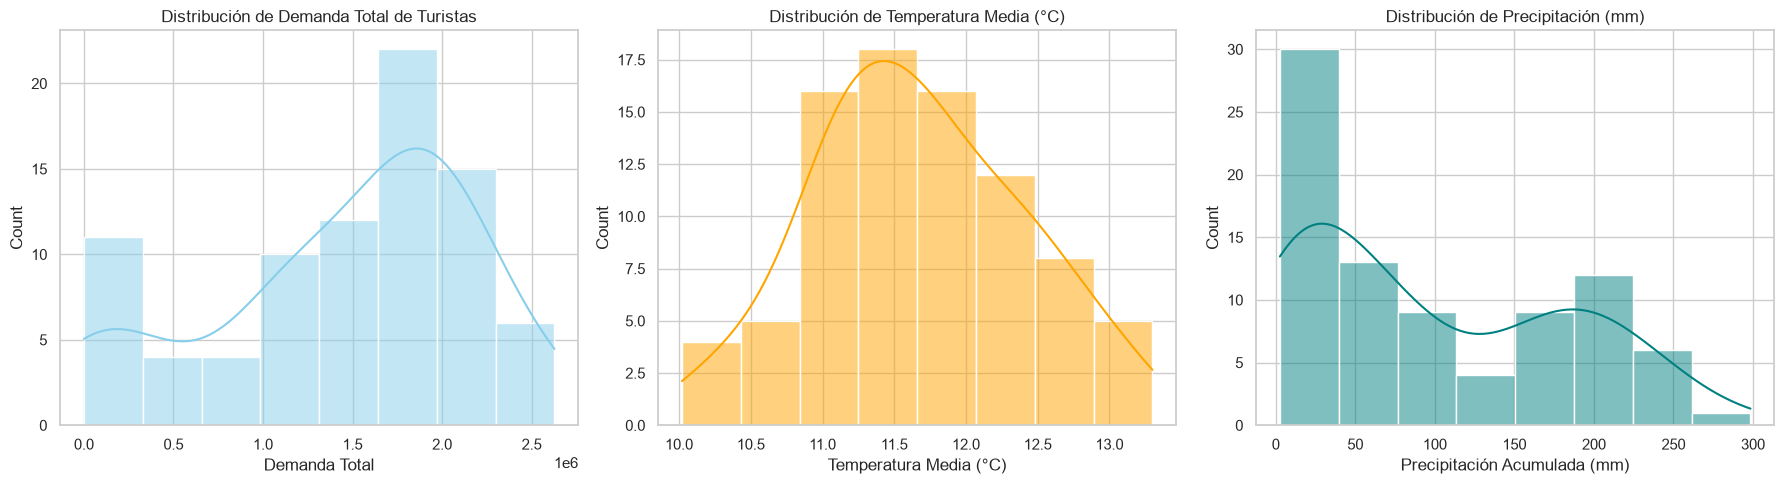

In [4]:
# Visualizamos la distribución de la demanda total y las variables climáticas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['demanda_total'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Demanda Total de Turistas')
axes[0].set_xlabel('Demanda Total')

sns.histplot(df['temp_mean'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribución de Temperatura Media (°C)')
axes[1].set_xlabel('Temperatura Media (°C)')

sns.histplot(df['precipitacion'], kde=True, ax=axes[2], color='teal')
axes[2].set_title('Distribución de Precipitación (mm)')
axes[2].set_xlabel('Precipitación Acumulada (mm)')

plt.tight_layout()
plt.show()

### 3. Análisis Estacional y Patrones Cíclicos

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1820\3187750362.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=demanda_mensual, x='nombre_mes', y='demanda_total', palette='viridis')


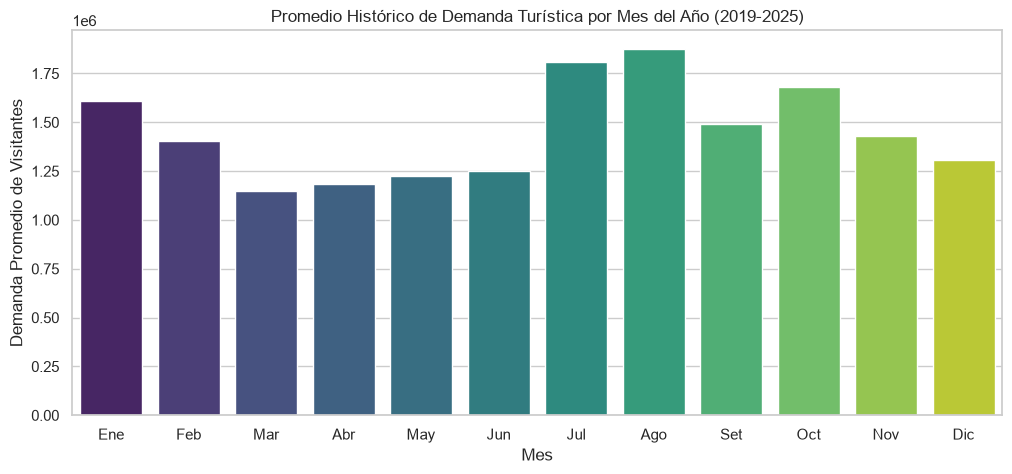

In [5]:
# Agrupamos la demanda promedio por mes del año (ID_MES) para identificar temporada alta y baja
demanda_mensual = df.groupby('ID_MES')['demanda_total'].mean().reset_index()
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Set', 'Oct', 'Nov', 'Dic']
demanda_mensual['nombre_mes'] = nombres_meses

plt.figure(figsize=(12, 5))
sns.barplot(data=demanda_mensual, x='nombre_mes', y='demanda_total', palette='viridis')
plt.title('Promedio Histórico de Demanda Turística por Mes del Año (2019-2025)')
plt.xlabel('Mes')
plt.ylabel('Demanda Promedio de Visitantes')
plt.show()

### 4. Análisis de Correlación Clima vs. Demanda

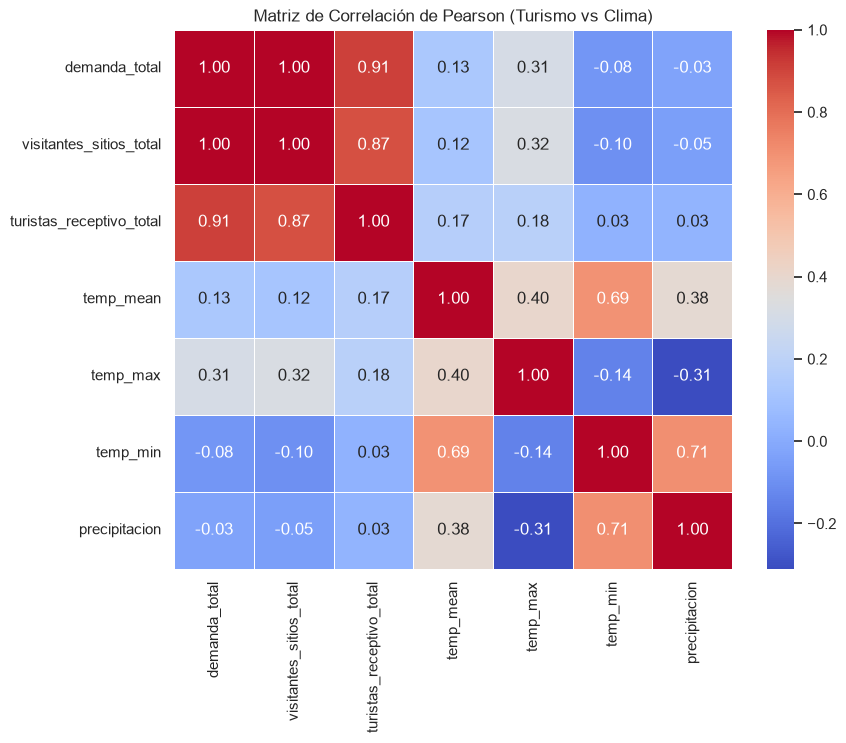

In [6]:
# Calculamos la matriz de correlación entre demanda y variables climáticas
cols_corr = ['demanda_total', 'visitantes_sitios_total', 'turistas_receptivo_total', 'temp_mean', 'temp_max', 'temp_min', 'precipitacion']
matriz_corr = df[cols_corr].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Pearson (Turismo vs Clima)')
plt.show()

### 5. Detección y Tratamiento de Valores Atípicos (Anomalía COVID-2020)

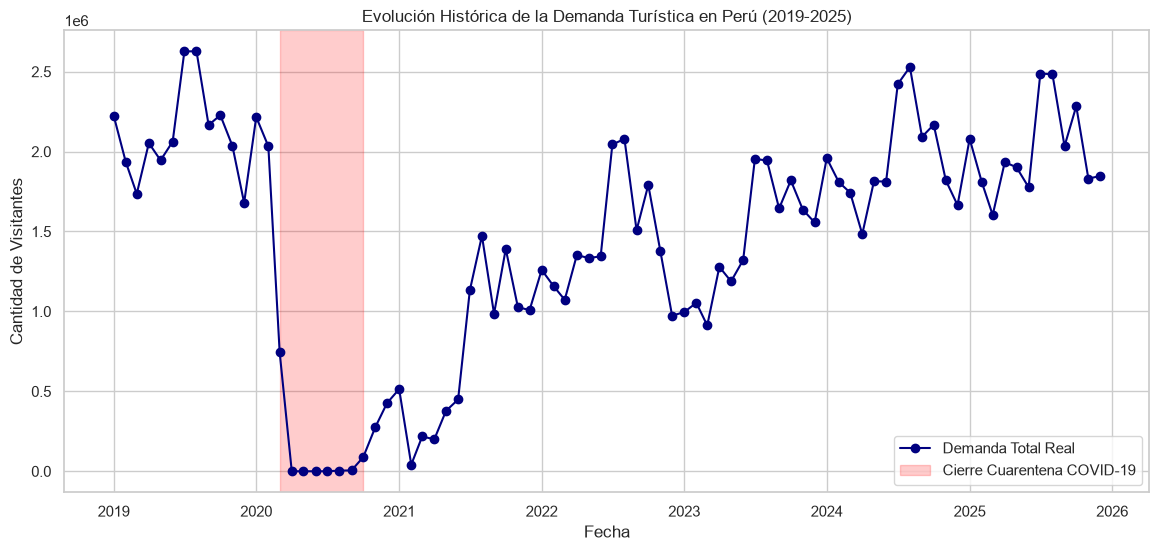

In [7]:
# Graficamos la serie de tiempo completa destacando el periodo atípico de la pandemia en 2020
plt.figure(figsize=(14, 6))
plt.plot(df['fecha'], df['demanda_total'], marker='o', color='navy', label='Demanda Total Real')
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2020-10-01'), color='red', alpha=0.2, label='Cierre Cuarentena COVID-19')

plt.title('Evolución Histórica de la Demanda Turística en Perú (2019-2025)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Visitantes')
plt.legend()
plt.show()

### 📌 Conclusiones del EDA (Fase 2)
1. **Estacionalidad Marcada:** Los picos de alta demanda turística se concentran en los meses de **Julio y Agosto** (vacaciones escolares y fiestas patrias) así como en **Octubre**.
2. **Impacto Climático:** Se observa una correlación negativa moderada entre las precipitaciones y la demanda turística; las lluvias de verano (Enero-Marzo en sierra) coinciden con los valles más bajos de afluencia.
3. **Tratamiento del Outlier 2020:** El periodo entre marzo y septiembre de 2020 presentó una caída cercana a cero por las restricciones estrictas de movilidad. En la **Fase 3 (Feature Engineering)** se creará una variable regresora/festivo especial (*holiday/lockdown effect*) para aislar este impacto en el modelo **Meta Prophet** y evitar sesgar las proyecciones futuras.